# Dynamic Sector Correlations and Structural Compression in Financial Markets
## Overview
This project explores how relationships between different sectors of the stock market change over time, with a particular focus on periods of financial instability. Traditional portfolio theory assumes that correlations between assets remain relatively stable and that diversification consistently reduces risk. However, historical market behavior suggests that these relationships are dynamic and often strengthen significantly during crises, reducing the effectiveness of diversification.

## Objective
The primary objectives of this study are to:
- Analyze how sector correlations evolve across different market regimes  
- Investigate whether market shocks propagate between sectors with observable lead–lag effects  
- Examine how markets become increasingly synchronized during periods of financial stress (structural compression)  

## Data
The analysis uses approximately 25 years (1999–2024) of daily data from S&P 500 sector ETFs, representing major sectors of the U.S. economy. Price series are transformed into logarithmic returns to support statistical, time-series, and correlation-based analysis.

## Methodology
The study includes:
- Visualization of sector price movements and return behavior  
- Correlation analysis across both stable and crisis periods  
- Rolling statistical measures to capture time-varying relationships  
- Preliminary analysis of lead–lag dynamics between sectors  
- Principal Component Analysis (PCA) to measure structural market compression over time  

## Expected Findings
The analysis is expected to show that:
- Sector correlations increase significantly during periods of financial crisis  
- Diversification benefits weaken as markets become more synchronized  
- Structural relationships between sectors evolve over time rather than remaining fixed  
- Crisis periods exhibit stronger systemic behavior across the broader market  

---

**Course:** Financial Markets – From Fundamentals to AI-Driven Analytics  
**Type:** Research Project  

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

plt.style.use('default')

In [5]:
tickers = ["XLK", "XLF", "XLE", "XLV", "XLY", "XLP", "XLI", "XLB", "XLU"]

start_date = "1999-01-01"
end_date = "2025-01-01"

In [84]:
data = yf.download(tickers, start=start_date, end=end_date)["Close"]

data.head()

/tmp/ipykernel_4135/2083226888.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)["Close"]
[*********************100%***********************]  9 of 9 completed


Ticker,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,
1999-01-04,5.945389,5.752040,11.223307,15.013254,12.277926,14.216936,5.817026,17.397732,9.563577
1999-01-05,6.091238,5.721218,11.328063,15.323210,12.591849,14.324133,5.887299,17.670235,9.724696
1999-01-06,6.198479,5.909995,11.687215,15.652531,12.963908,14.497309,5.948405,17.963694,10.000900
1999-01-07,6.151295,5.883031,11.866784,15.516929,12.923209,14.332384,5.927014,17.879845,9.989390
1999-01-08,6.361485,5.909995,11.941606,15.633157,12.975538,14.274649,5.960620,18.099936,10.000900


In [8]:
# Check missing values
print(data.isnull().sum())

# Forward fill gaps
data = data.ffill()

# Drop any remaining missing values
data = data.dropna()

Ticker
XLB    0
XLE    0
XLF    0
XLI    0
XLK    0
XLP    0
XLU    0
XLV    0
XLY    0
dtype: int64


In [48]:
returns = np.log(data / data.shift(1))
returns = returns.dropna()

Ticker,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
count,6540.000000,6540.000000,6540.000000,6540.000000,6540.000000,6540.000000,6540.000000,6540.000000,6540.000000
mean,0.000295,0.000301,0.000220,0.000330,0.000343,0.000256,0.000281,0.000313,0.000375
std,0.014991,0.018238,0.018119,0.013379,0.016283,0.009620,0.012221,0.011277,0.014302
min,-0.132527,-0.224910,-0.182321,-0.120408,-0.148663,-0.098667,-0.120561,-0.103817,-0.135460
25%,-0.007093,-0.008422,-0.006916,-0.005735,-0.006681,-0.004381,-0.005545,-0.005099,-0.006102
50%,0.000728,0.000691,0.000555,0.000834,0.001020,0.000477,0.000886,0.000571,0.000914
75%,0.008268,0.009798,0.007836,0.006997,0.008085,0.005249,0.006690,0.006205,0.007580
max,0.131534,0.152503,0.152394,0.119126,0.149296,0.081678,0.120388,0.113816,0.093265


In [11]:
sector_labels = {
    "XLB": "Materials",
    "XLE": "Energy",
    "XLF": "Financials",
    "XLI": "Industrials",
    "XLK": "Technology",
    "XLP": "Consumer Staples",
    "XLU": "Utilities",
    "XLV": "Health Care",
    "XLY": "Consumer Discretionary"
}

data_named = data.rename(columns=sector_labels)
returns_named = returns.rename(columns=sector_labels)

custom_colors = {
    "Technology": "#1f77b4",
    "Financials": "#d62728",
    "Industrials": "#2ca02c",
    "Consumer Discretionary": "#ff7f0e",
    "Consumer Staples": "#9467bd",
    "Materials": "#8c564b",
    "Health Care": "#e377c2",
    "Utilities": "#7f7f7f",
    "Energy": "#bcbd22"
}

## Exploratory data analysis (Data description, Time Series and Returns Analysis)

In [52]:
data_named.describe()

Ticker,Materials,Energy,Financials,Industrials,Technology,Consumer Staples,Utilities,Health Care,Consumer Discretionary
count,6541.000000,6541.000000,6541.000000,6541.000000,6541.000000,6541.000000,6541.000000,6541.000000,6541.000000
mean,17.736167,19.543014,18.110019,43.333304,26.025625,31.241358,14.673957,51.681805,32.318790
std,11.020867,9.674870,8.801457,30.395138,26.585578,19.894201,9.034585,38.894546,26.784496
min,4.850728,5.175654,3.680431,11.034395,4.308518,9.923348,3.370602,14.787010,6.489667
25%,8.688890,11.875227,11.987967,19.422249,8.773305,13.929129,7.190270,20.936213,11.796931
50%,14.053934,20.388416,15.410413,28.066769,13.720771,22.019709,10.972553,28.044121,17.076956
75%,24.029081,24.238245,22.397757,63.314079,31.589439,43.869579,20.905945,75.245758,48.717499
max,47.402695,46.368492,50.162365,140.931015,119.627632,80.518448,39.704628,152.626602,118.226120


### Time Series Ploting





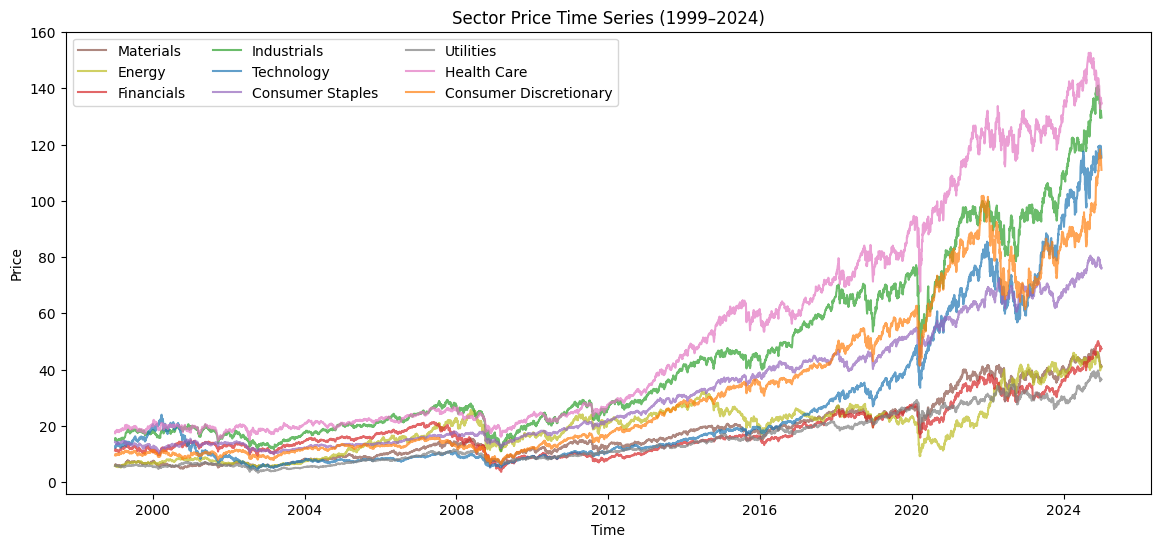

In [12]:
plt.figure(figsize=(14,6))

for col in data_named.columns:
    plt.plot(data_named.index, data_named[col], label=col, alpha=0.7, color=custom_colors[col])

plt.title("Sector Price Time Series (1999–2024)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend(ncol=3)
plt.show()

### Plotting returns


In [53]:
returns_named.describe()

Ticker,Materials,Energy,Financials,Industrials,Technology,Consumer Staples,Utilities,Health Care,Consumer Discretionary
count,6540.000000,6540.000000,6540.000000,6540.000000,6540.000000,6540.000000,6540.000000,6540.000000,6540.000000
mean,0.000295,0.000301,0.000220,0.000330,0.000343,0.000256,0.000281,0.000313,0.000375
std,0.014991,0.018238,0.018119,0.013379,0.016283,0.009620,0.012221,0.011277,0.014302
min,-0.132527,-0.224910,-0.182321,-0.120408,-0.148663,-0.098667,-0.120561,-0.103817,-0.135460
25%,-0.007093,-0.008422,-0.006916,-0.005735,-0.006681,-0.004381,-0.005545,-0.005099,-0.006102
50%,0.000728,0.000691,0.000555,0.000834,0.001020,0.000477,0.000886,0.000571,0.000914
75%,0.008268,0.009798,0.007836,0.006997,0.008085,0.005249,0.006690,0.006205,0.007580
max,0.131534,0.152503,0.152394,0.119126,0.149296,0.081678,0.120388,0.113816,0.093265


### Return Time Series

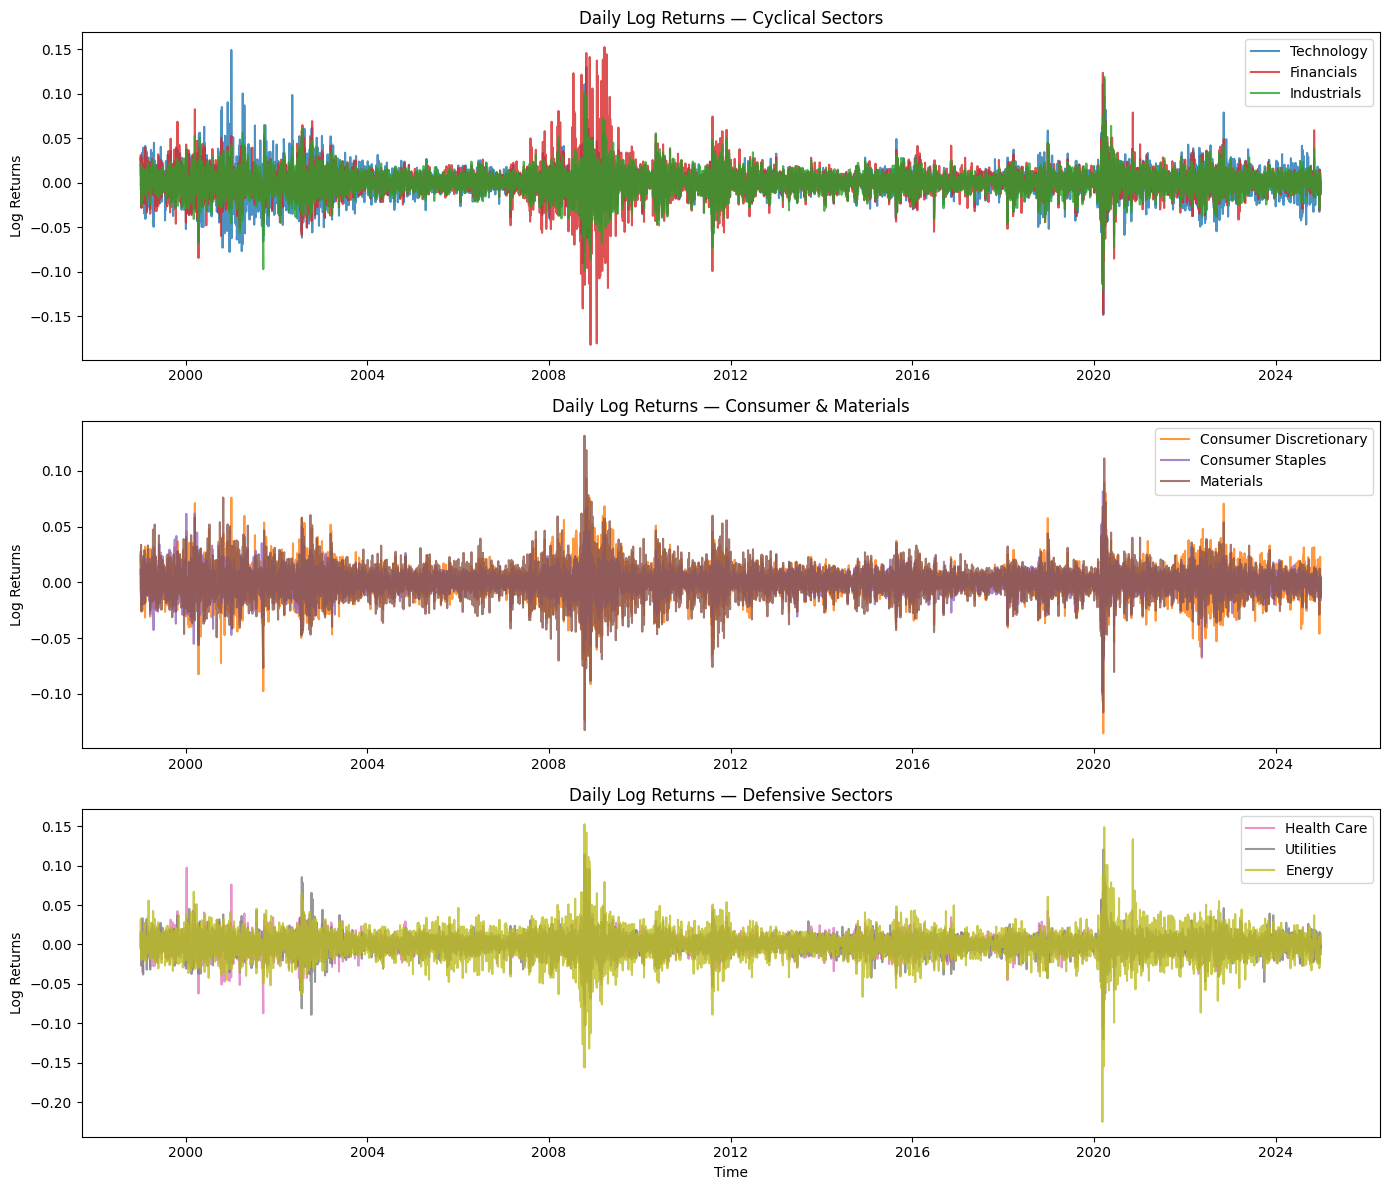

In [59]:
plt.figure(figsize=(14,12))

market_return = returns_named.mean(axis=1)

groups = {
    "Cyclical Sectors": ["Technology", "Financials", "Industrials"],
    "Consumer & Materials": ["Consumer Discretionary", "Consumer Staples", "Materials"],
    "Defensive Sectors": ["Health Care", "Utilities", "Energy"]
}



for i, (title, cols) in enumerate(groups.items(), 1):
    plt.subplot(3,1,i)

    for col in cols:
        plt.plot(
            returns_named.index,
            returns_named[col],
            label=col,
            color=custom_colors[col],
            alpha=0.8
        )

    plt.title(f"Daily Log Returns — {title}")
    plt.ylabel("Log Returns")
    plt.legend()

plt.xlabel("Time")
plt.tight_layout()
plt.show()


### Rolling Returns

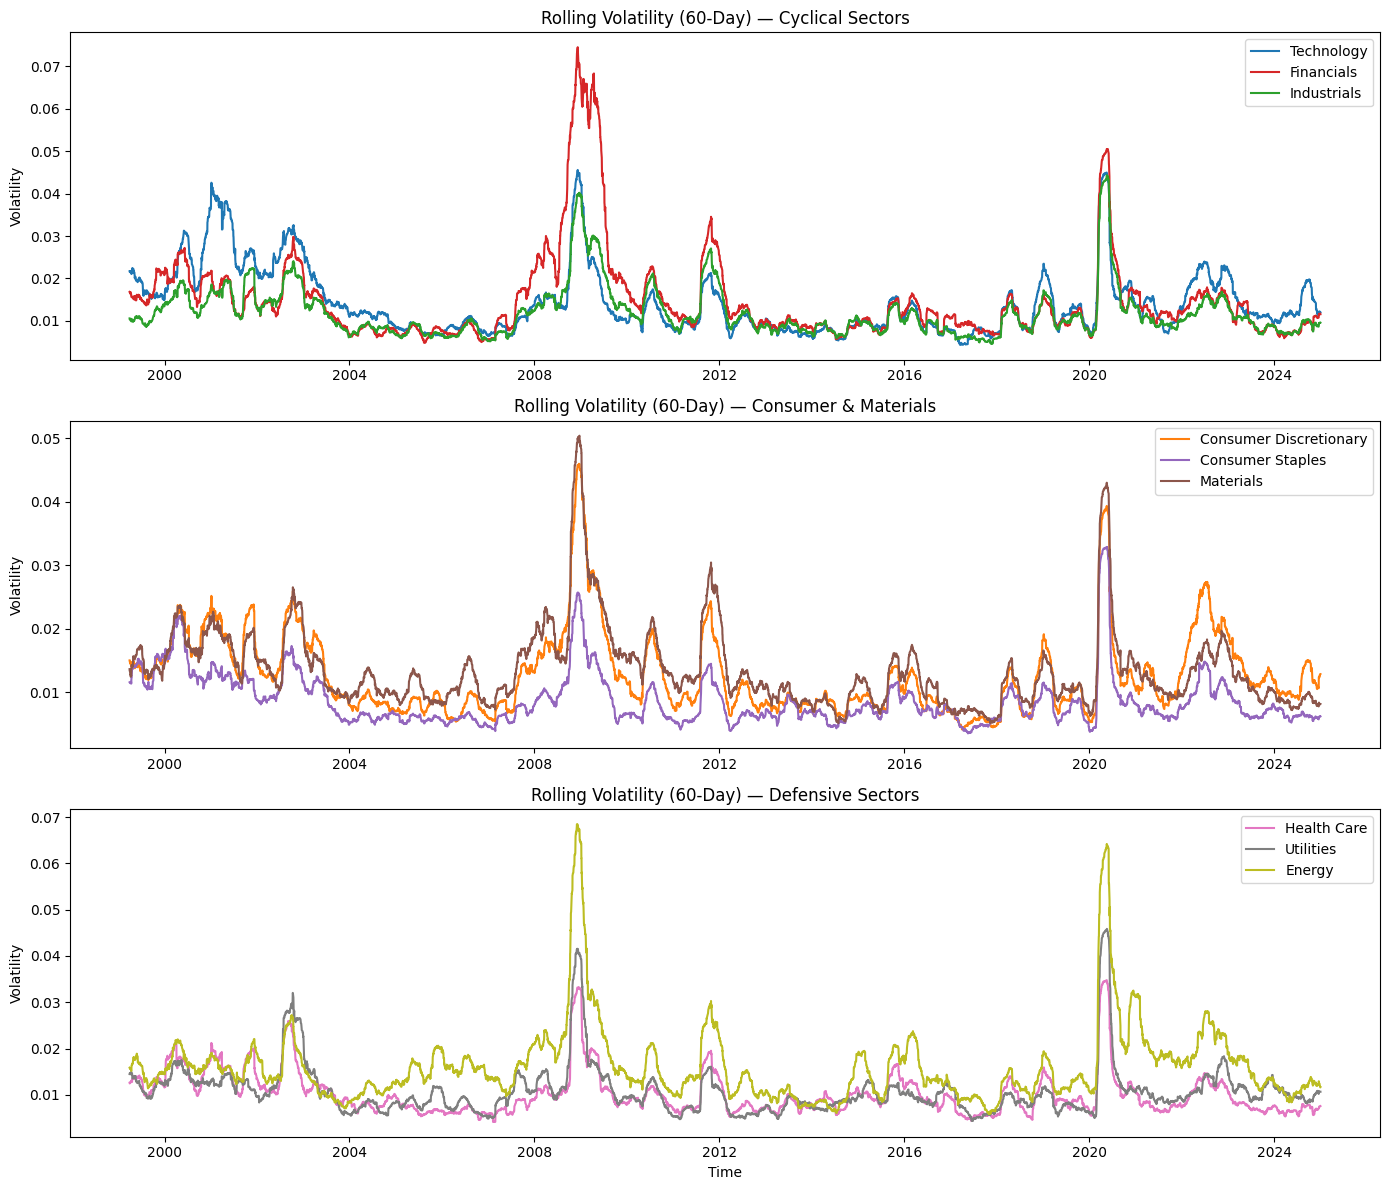

In [15]:
vol = returns_named.rolling(60).std()

plt.figure(figsize=(14,12))

for i, (title, cols) in enumerate(groups.items(), 1):
    plt.subplot(3,1,i)

    for col in cols:
        plt.plot(
            vol.index,
            vol[col],
            label=col,
            color=custom_colors[col]
        )

    plt.title(f"Rolling Volatility (60-Day) — {title}")
    plt.ylabel("Volatility")
    plt.legend()

plt.xlabel("Time")
plt.tight_layout()
plt.show()

### Cumulative Returns Analysis





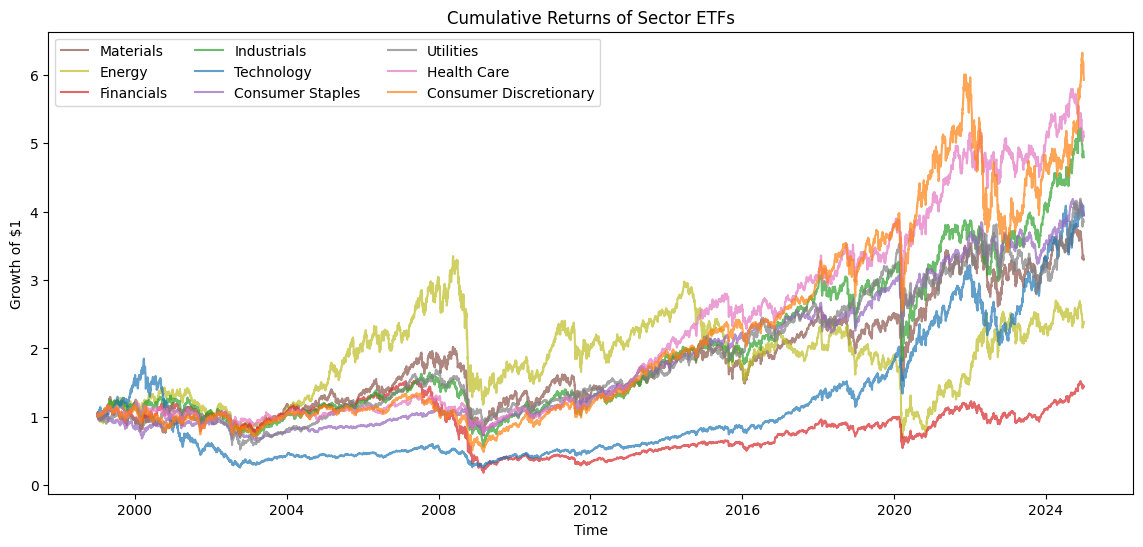

In [16]:
cum_returns = (1 + returns_named).cumprod()

plt.figure(figsize=(14,6))

for col in cum_returns.columns:
    plt.plot(cum_returns.index, cum_returns[col], label=col, alpha=0.7, color=custom_colors[col])

plt.title("Cumulative Returns of Sector ETFs")
plt.xlabel("Time")
plt.ylabel("Growth of $1")
plt.legend(ncol=3)
plt.show()

### Observations from EDA

We can observe that sectors retain fairly distinct behavior even outside major crisis periods. Cyclical sectors such as Technology, Financials, and Industrials generally show larger fluctuations and stronger long-term growth, suggesting higher sensitivity to economic conditions and investor sentiment. In contrast, sectors like Utilities, Consumer Staples, and Health Care appear comparatively stable, with smoother trajectories and lower sustained volatility.
Energy behaves somewhat differently from the rest of the market altogether. Its volatility remains structurally elevated across much of the sample, possibly because it is influenced not only by broader markets but also by commodity cycles and geopolitical events.

From these graphs we can observe certain systemic events which cause elevated volatility spikes.

Major: 2008 (financial crisis due to property due to housing bubble), 2020 (COVID-19)

Minor: 2002 (Dot com bubble), 2012 (Unknown, believed to be due to European debt crisis), 2023 (Geopolitical tensions Russia vs Ukraine)

## Correlation Analysis

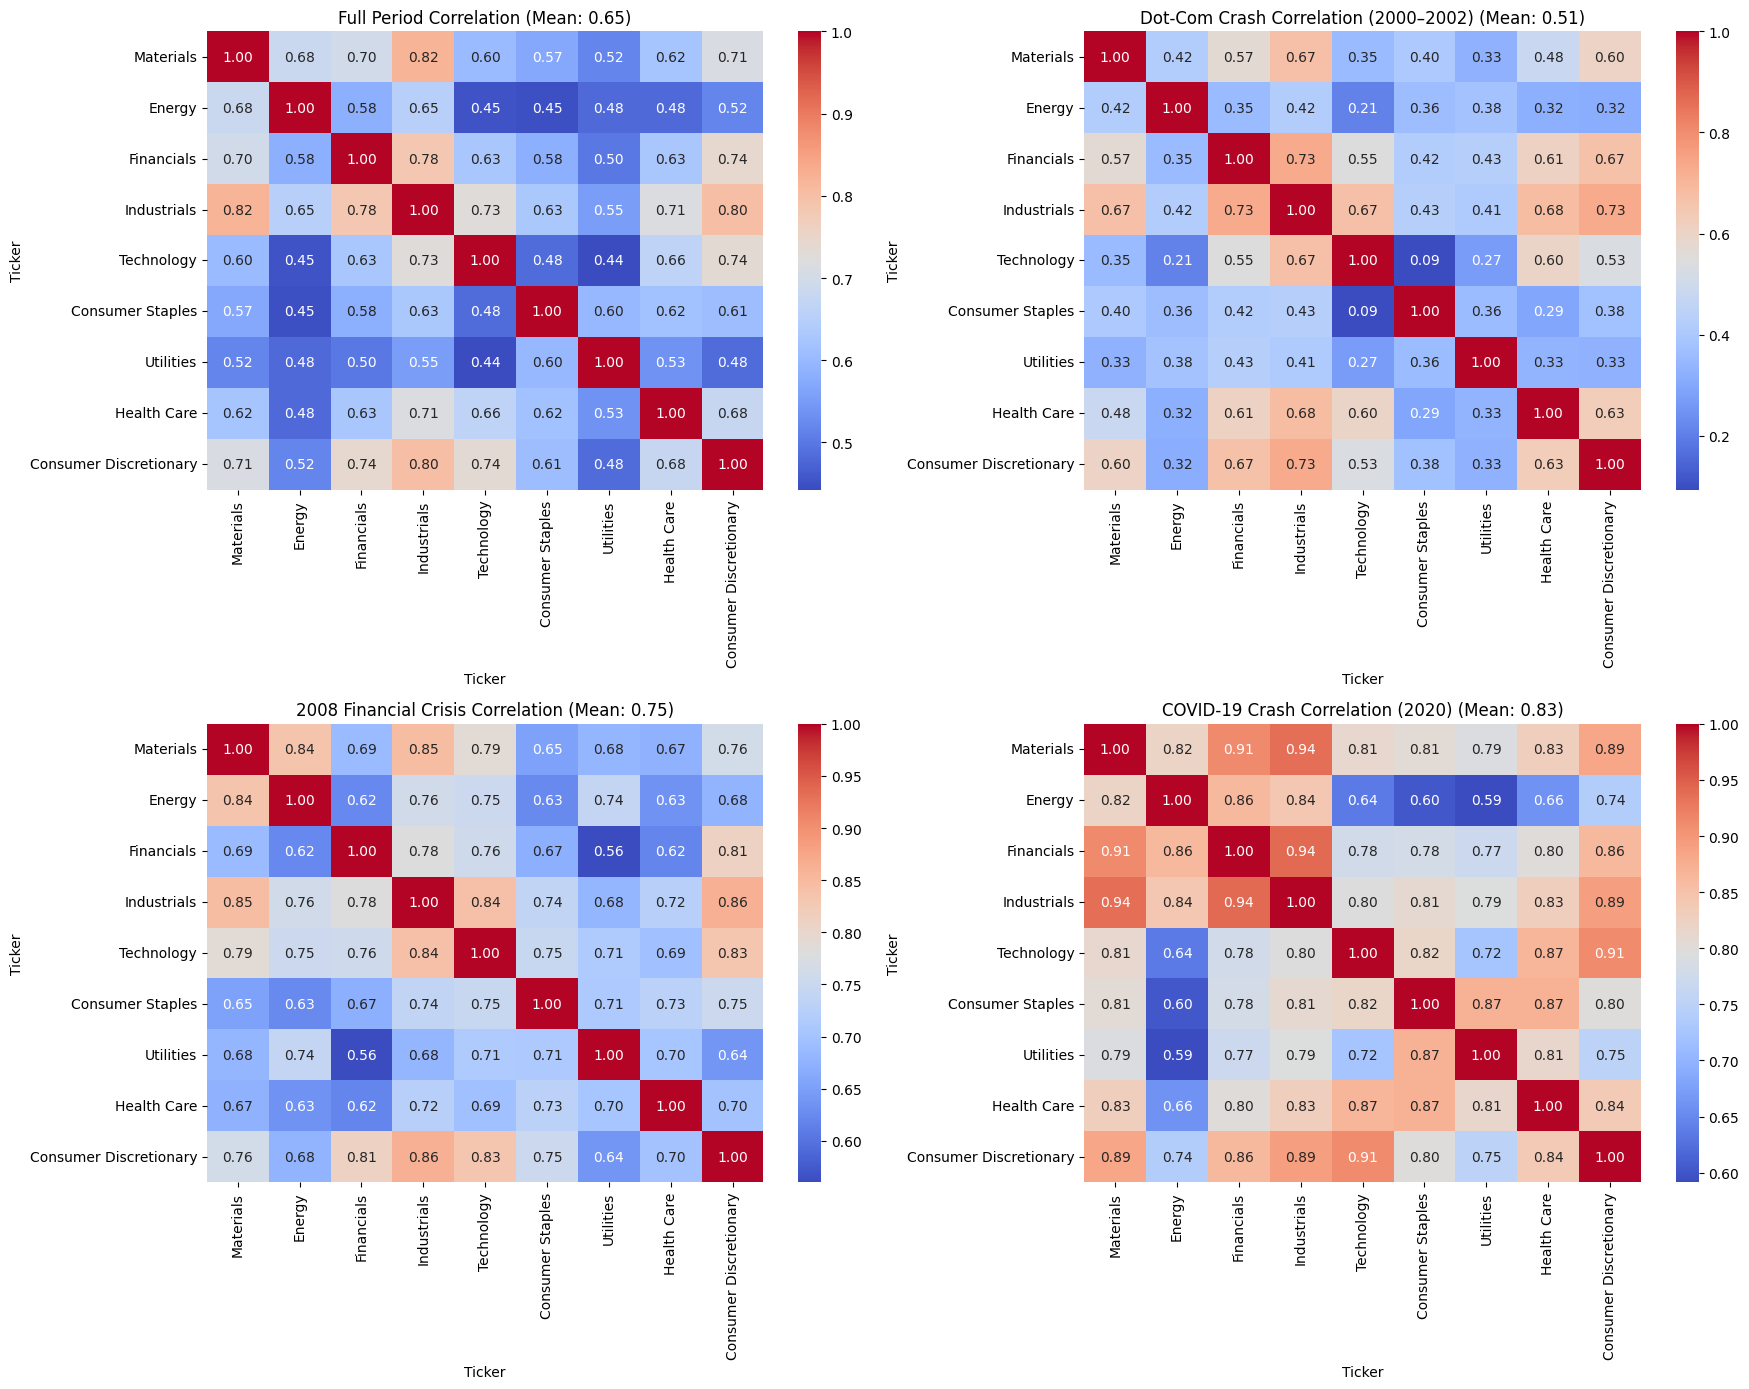

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ---------------- FULL PERIOD ----------------
corr_matrix = returns_named.corr()
mean_full = corr_matrix.mean().mean()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[0, 0]
)
axes[0, 0].set_title(f"Full Period Correlation (Mean: {mean_full:.2f})")

# ---------------- DOT-COM BUBBLE ----------------
dotcom_period = returns_named.loc["2000-01-01":"2002-12-31"]
corr_dotcom = dotcom_period.corr()
mean_dotcom = corr_dotcom.mean().mean()

sns.heatmap(
    corr_dotcom,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[0, 1]
)
axes[0, 1].set_title(f"Dot-Com Crash Correlation (2000–2002) (Mean: {mean_dotcom:.2f})")

# ---------------- 2008 FINANCIAL CRISIS ----------------
crisis_2008 = returns_named.loc["2007-01-01":"2009-12-31"]
corr_2008 = crisis_2008.corr()
mean_2008 = corr_2008.mean().mean()

sns.heatmap(
    corr_2008,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[1, 0]
)
axes[1, 0].set_title(f"2008 Financial Crisis Correlation (Mean: {mean_2008:.2f})")

# ---------------- COVID CRASH ----------------
covid_period = returns_named.loc["2020-01-01":"2020-12-31"]
corr_covid = covid_period.corr()
mean_covid = corr_covid.mean().mean()

sns.heatmap(
    corr_covid,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[1, 1]
)
axes[1, 1].set_title(f"COVID-19 Crash Correlation (2020) (Mean: {mean_covid:.2f})")

plt.tight_layout()
plt.show()

### Analysis

We can clearly observe that correlation is clearly higher during most crisis, but surprisingly it is lower in the dot com crisis compared to the mean of entire time period. This indicates both crisis are different in nature, one originated from systemic events while the other originated from correction of sector specific bubble.

A contradiction, due ot fact that 2008 crisis was also caused by property price bubble.
Maybe due to the fact that property was a dependency for almost all industry.

Does it also imply that another tech bubble will also impact entire market as almost all industry is interlinked and dependent on tech somehow, unlike 2002 where it was rather independent?

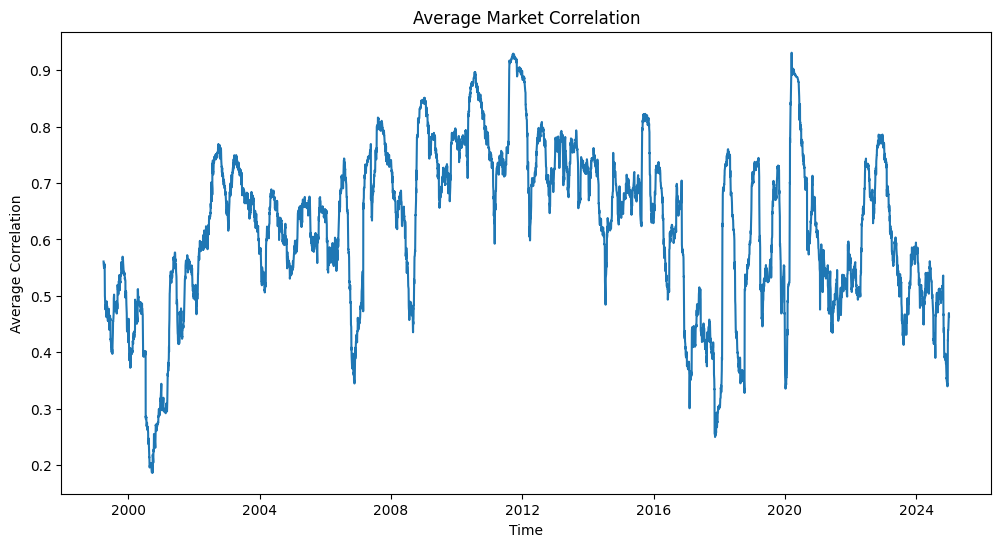

In [92]:
rolling_corr = returns_named.rolling(window=60).corr()

avg_corr = rolling_corr.groupby(level=0).mean().mean(axis=1)

plt.figure(figsize=(12,6))
plt.plot(avg_corr)
plt.title("Average Market Correlation")
plt.xlabel("Time")
plt.ylabel("Average Correlation")
plt.show()

There was a big dip just before the dot com crisis in rolling correlation, which we believe is the sign of the bubble forming as tech decoupled a lot from other sectors. Although just a hypothesis, it is a possible that sector specific crisis may lead to a large drop in correlation due to overvaluation of a particular sector, as investor capital becomes heavily concentrated in that sector, causing it to move independently from broader market fundamentals before eventually reconnecting during the correction phase.
Though not verifiable by a single event so jsut take it for granted.

## Correlation Asymmetry

We now examine whether correlations behave differently during rising and falling markets.

The dataset is divided into:
- Upside regimes (top 20% market returns)
- Downside regimes (bottom 20% market returns)

In [60]:
# Define thresholds
upper_thresh = market_return.quantile(0.80)
lower_thresh = market_return.quantile(0.20)

print("Upper Threshold:", upper_thresh)
print("Lower Threshold:", lower_thresh)

# Split into regimes
returns_up = returns_named[market_return >= upper_thresh]
returns_down = returns_named[market_return <= lower_thresh]

print("Upside samples:", len(returns_up))
print("Downside samples:", len(returns_down))

Upper Threshold: 0.007154605400424256
Lower Threshold: -0.00623257049655676
Upside samples: 1308
Downside samples: 1308


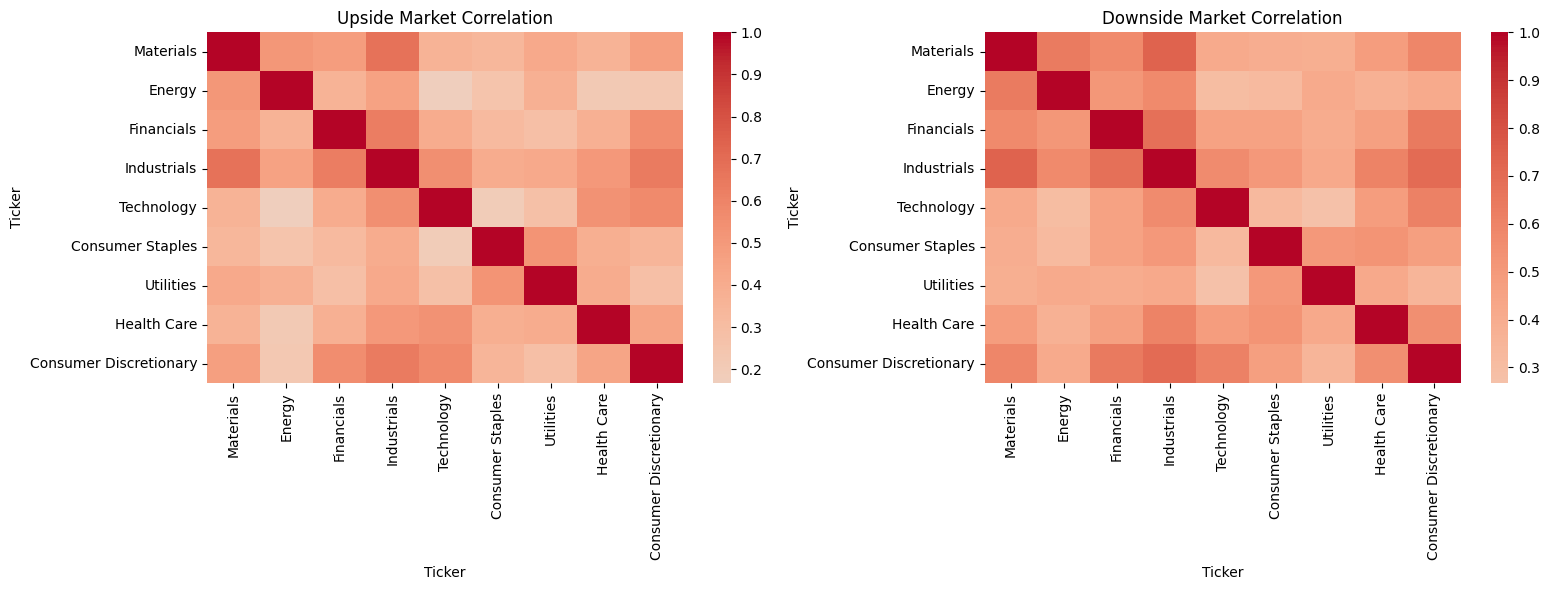

In [66]:
corr_up = returns_up.corr()
corr_down = returns_down.corr()

fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.heatmap(corr_up, ax=axes[0], cmap='coolwarm', center=0)
axes[0].set_title("Upside Market Correlation")

sns.heatmap(corr_down, ax=axes[1], cmap='coolwarm', center=0)
axes[1].set_title("Downside Market Correlation")

plt.tight_layout()
plt.show()

We can clearly observe that correlations are generally higher during downside market regimes compared to upside regimes. During positive market conditions, sectors still retain some degree of independent behavior, but during declines they begin moving much more uniformly. This suggests that diversification weakens during stress periods. This implies there are more factors to correlation and that diversifying without not considering them may give unexpected results.

### Correlation Asymmetry and Diversification Breakdown

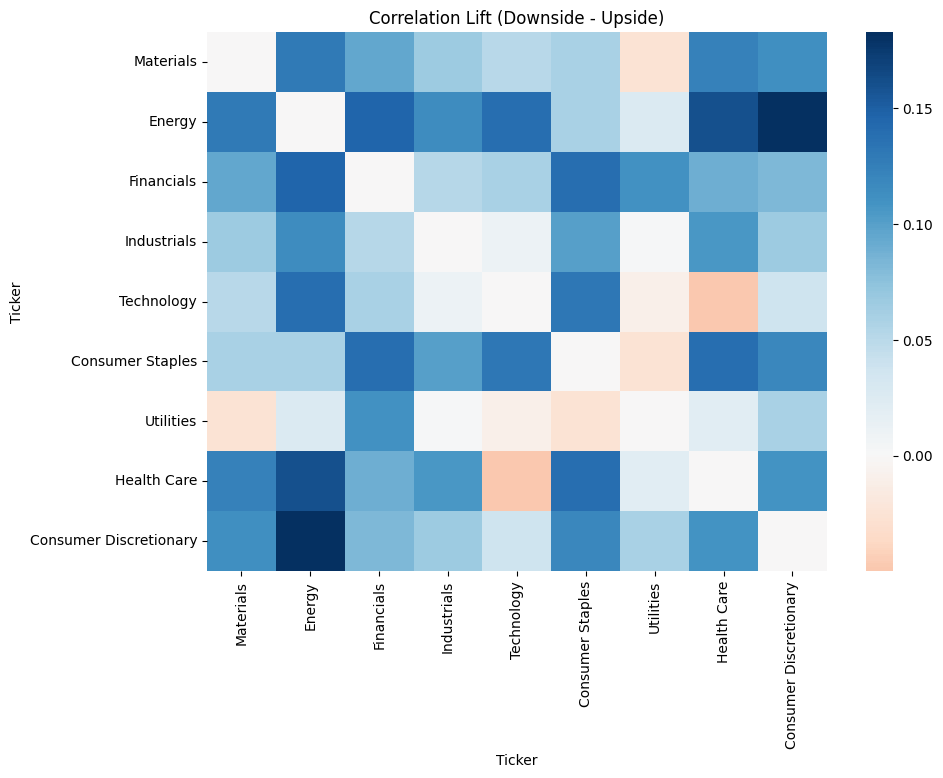

In [62]:
corr_lift = corr_down - corr_up

plt.figure(figsize=(10,7))

sns.heatmap(corr_lift, cmap='RdBu', center=0)

plt.title("Correlation Lift (Downside - Upside)")
plt.show()



The correlation lift matrix shows that most sector relationships strengthen during downside market regimes, indicating that diversification weakens under stress.

Energy appears repeatedly among the strongest lift pairs, suggesting that it behaves relatively independently during normal periods but becomes much more synchronized with the broader market during downturns.

Interestingly, even traditionally defensive sectors such as Consumer Staples and Health Care exhibit noticeable increases in correlation with cyclical sectors during stress periods. This suggests that broad market fear can temporarily overwhelm sector-specific behaviour.

### Correlation Lift Top Pairs

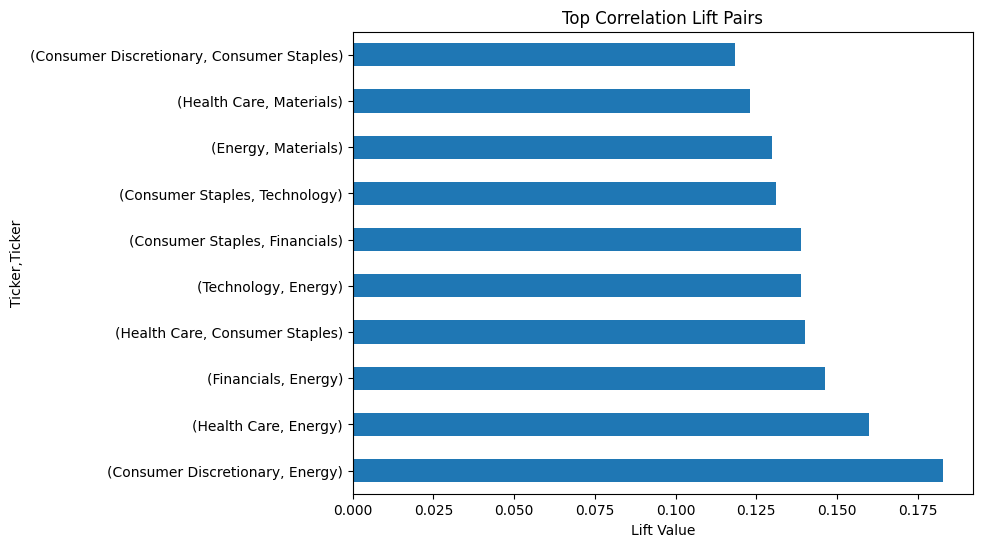

In [67]:
pairs = corr_lift.where(np.triu(np.ones(corr_lift.shape), k=1).astype(bool))
pairs = pairs.unstack().dropna()

top_pairs = pairs.sort_values(ascending=False).head(10)

top_pairs.plot(kind='barh', figsize=(8,6))
plt.title("Top Correlation Lift Pairs")
plt.xlabel("Lift Value")
plt.show()

Ranking the correlation lift values makes the asymmetry between normal and stressed market conditions easier to interpret directly.

Energy appears repeatedly among the highest lift pairs, particularly with Consumer Discretionary, Health Care, and Financials. This may indicate that Energy behaves relatively independently during normal market conditions but becomes strongly tied to broader macroeconomic sentiment during downturns.

Interestingly, some traditionally defensive sectors such as Consumer Staples and Health Care also exhibit meaningful lift with cyclical sectors. This suggests that during sufficiently strong market stress, broad market fear may begin overwhelming sector-specific fundamentals, reducing the practical effectiveness of diversification.

Overall, the rankings reinforce the idea that market structure behaves asymmetrically across regimes rather than maintaining fixed relationships through time.

The fluctuation in correlation increases unpredictability in results of diversification, which may make them less appealing contrary to common beliefs.

### Time-Varying Structural Compression

We track how correlation asymmetry evolves over time by comparing upside and downside correlations.

### Dynamic Correlation Regimes

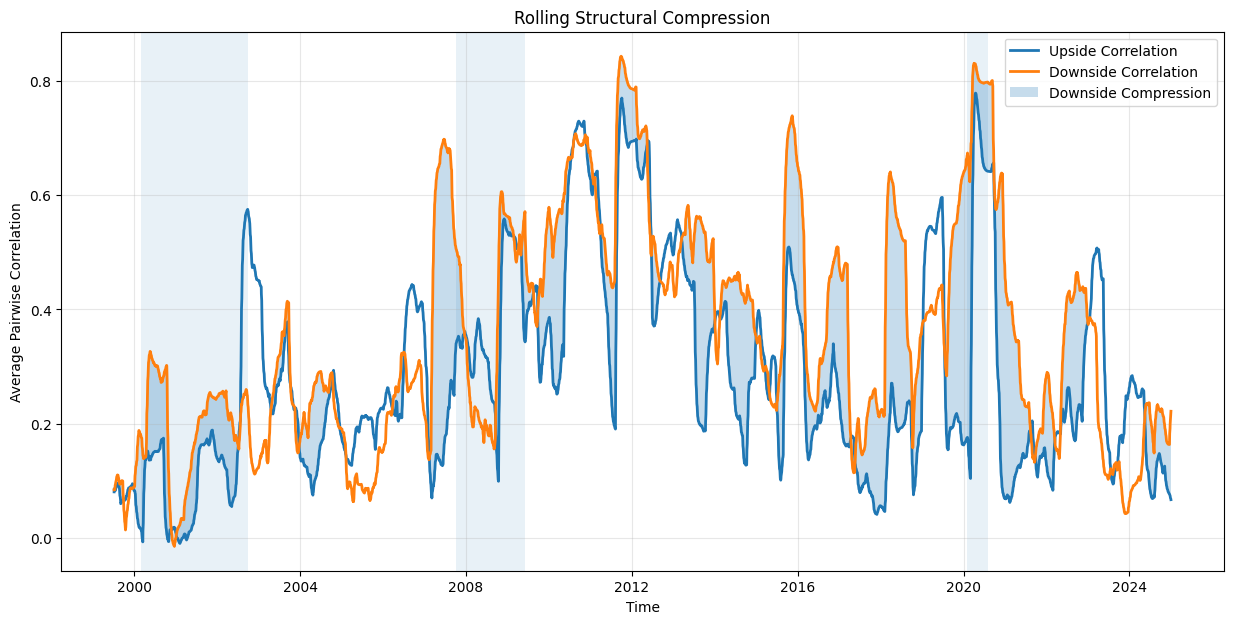

In [38]:
# Parameters
window = 126
smooth = 20

# Market proxy
market = returns_named.mean(axis=1)

# Rolling correlations
up_corr = []
down_corr = []
dates = []

for i in range(window, len(returns_named)):

    r = returns_named.iloc[i-window:i]
    m = market.iloc[i-window:i]

    # Regime filters
    up = r[m >= m.quantile(0.80)]
    down = r[m <= m.quantile(0.20)]

    if len(up) < 10 or len(down) < 10:
        continue

    # Average pairwise correlations
    idx = np.triu_indices(r.shape[1], k=1)

    up_corr.append(up.corr().values[idx].mean())
    down_corr.append(down.corr().values[idx].mean())

    dates.append(returns_named.index[i])

# Series + smoothing
up_corr = pd.Series(up_corr, index=dates).ewm(span=smooth).mean()
down_corr = pd.Series(down_corr, index=dates).ewm(span=smooth).mean()

# Compression asymmetry
compression = down_corr - up_corr

# Plot
plt.figure(figsize=(15,7))

plt.plot(up_corr, label="Upside Correlation", linewidth=2)
plt.plot(down_corr, label="Downside Correlation", linewidth=2)

plt.fill_between(
    compression.index,
    up_corr,
    down_corr,
    where=(down_corr >= up_corr),
    alpha=0.25,
    label="Downside Compression"
)

# Crisis regimes
for start, end in [
    ("2000-03-01", "2002-10-01"),
    ("2007-10-01", "2009-06-01"),
    ("2020-02-01", "2020-08-01")
]:
    plt.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.10)

plt.title("Rolling Structural Compression")
plt.xlabel("Time")
plt.ylabel("Average Pairwise Correlation")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


Tracking upside and downside correlations separately reveals that market synchronization behaves differently across regimes.

During calmer periods, upside and downside correlations remain relatively close together. During stress periods, however, downside correlations rise much more sharply, indicating that sectors become increasingly synchronized during market declines.

The widening gap between the two series during major crises suggests that market structure is asymmetric rather than stable through time. Different crises also appear to produce different compression patterns, with some showing brief spikes while others remain elevated for extended periods.

## PCA and Structural Compression over Time Analysis

In [43]:
window = 60

pca_values = []
dates = []

for i in range(window, len(returns_named)):

    window_data = returns_named.iloc[i-window:i]

    # Drop missing values (important for PCA)
    window_data = window_data.dropna()

    if len(window_data) < window:
        continue

    # Apply PCA
    pca = PCA()
    pca.fit(window_data)

    # Store variance explained by first component
    pca_values.append(pca.explained_variance_ratio_[0])
    dates.append(returns_named.index[i])

In [44]:
pca_series = pd.Series(pca_values, index=dates)

# Smooth for clarity
pca_series = pca_series.ewm(span=20).mean()

pca_series.head()

,0
1999-04-01,0.586292
1999-04-05,0.583984
1999-04-06,0.581555
1999-04-07,0.580214
1999-04-08,0.579560


### Market Structural Compression

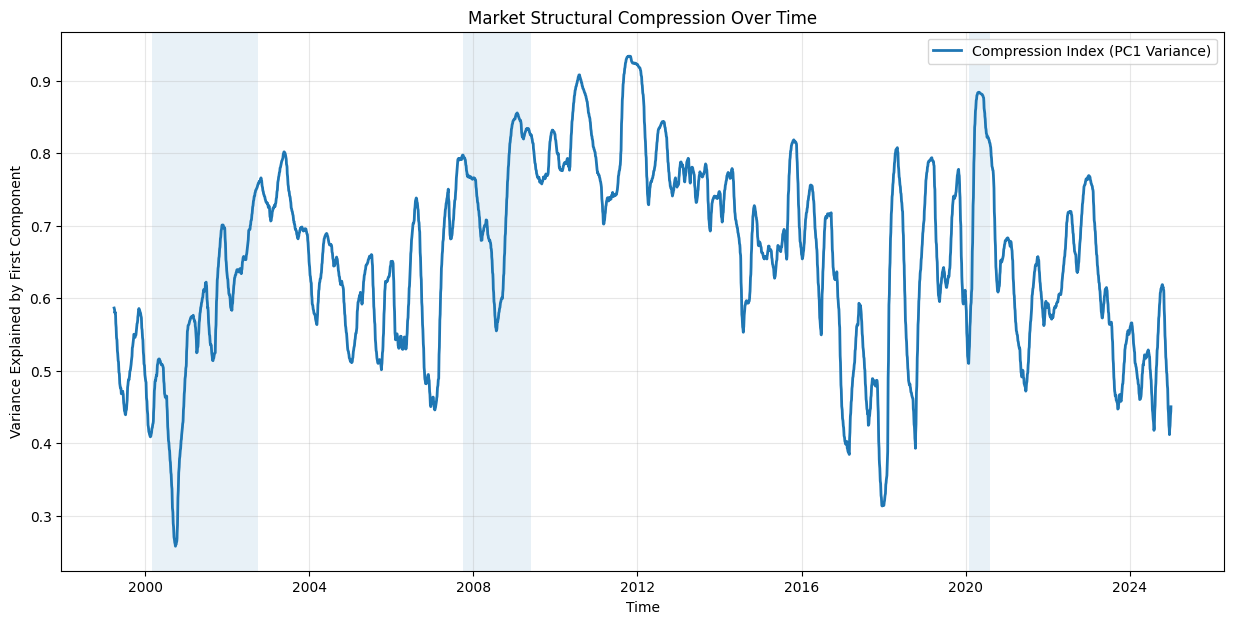

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

plt.plot(pca_series, linewidth=2, label="Compression Index (PC1 Variance)")

# Highlight crisis periods
for start, end in [
    ("2000-03-01", "2002-10-01"),
    ("2007-10-01", "2009-06-01"),
    ("2020-02-01", "2020-08-01")
]:
    plt.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.10)

plt.title("Market Structural Compression Over Time")
plt.xlabel("Time")
plt.ylabel("Variance Explained by First Component")

plt.legend()
plt.grid(alpha=0.3)

plt.show()



The Compression Index measures how much of total market movement can be explained by a single dominant factor at any point in time.

Higher values suggest that sectors are behaving increasingly alike, causing the market to compress toward a more synchronized and lower-dimensional structure. Lower values imply that sector-specific behaviour remains more differentiated, with multiple independent drivers active simultaneously.

One interesting feature is how differently the major crises appear structurally. The dot-com period begins with unusually low compression, suggesting strong divergence and speculative concentration within a smaller subset of sectors. In contrast, the 2008 financial crisis produces an extended period of extremely high compression, where the market behaves much more like a single coordinated system.

The COVID shock also creates a rapid compression spike, though the effect appears far shorter-lived than during 2008. it could have to do with the nature of crisis, one induced by pandemic and one by property bubble and overspeculation.

Another noticeable pattern is that compression does not always return immediately to calm-period levels after crises. There are several periods where synchronization remains structurally elevated for extended durations, suggesting that systemic stress may persist even after the initial market shock fades.

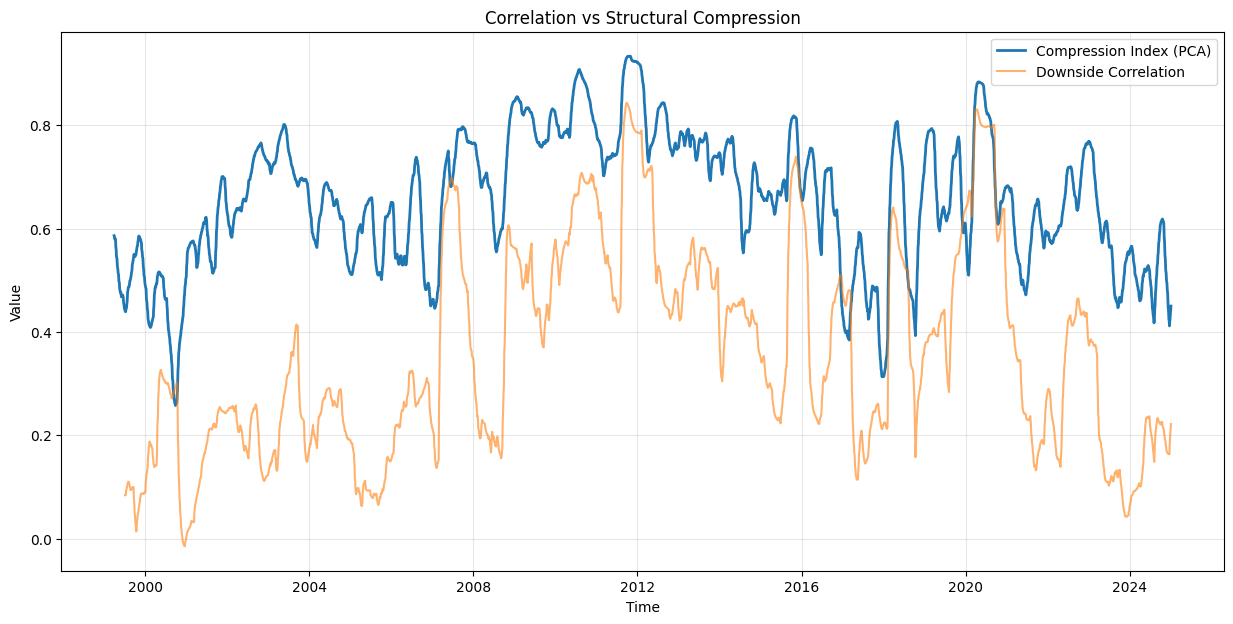

In [46]:
plt.figure(figsize=(15,7))

plt.plot(pca_series, label="Compression Index (PCA)", linewidth=2)
plt.plot(down_corr, label="Downside Correlation", alpha=0.6)

plt.title("Correlation vs Structural Compression")
plt.xlabel("Time")
plt.ylabel("Value")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

The strong alignment between downside correlation and the PCA Compression Index suggests that both metrics are capturing different views of the same underlying phenomenon: the collapse of sector independence during stress regimes.

As downside correlations rise, market variance becomes increasingly absorbed by a single dominant factor, causing the system to behave more like a unified structure rather than a collection of independent sectors.

### Effective Market Dimension

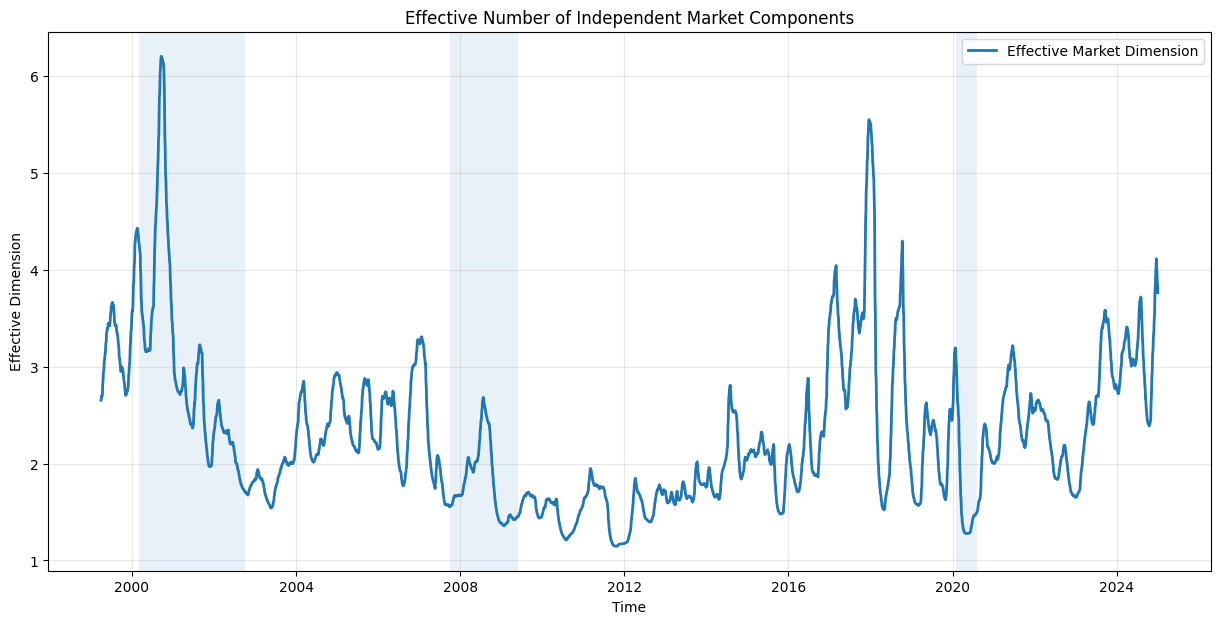

In [87]:
# Effective Market Dimension Over Time


window = 60

effective_dimension = []
dates = []

for i in range(window, len(returns_named)):

    window_data = returns_named.iloc[i-window:i].dropna()

    pca = PCA()
    pca.fit(window_data)

    # Eigenvalues normalized
    eigvals = pca.explained_variance_ratio_

    # Effective dimension
    neff = 1 / np.sum(eigvals**2)

    effective_dimension.append(neff)
    dates.append(returns_named.index[i])

# Series
neff_series = pd.Series(effective_dimension, index=dates)

# Smooth
neff_series = neff_series.ewm(span=20).mean()


# Plot


plt.figure(figsize=(15,7))

plt.plot(
    neff_series,
    linewidth=2,
    label="Effective Market Dimension"
)

# Crisis shading
for start, end in [

    ("2000-03-01", "2002-10-01"),
    ("2007-10-01", "2009-06-01"),
    ("2020-02-01", "2020-08-01")

]:
    plt.axvspan(
        pd.Timestamp(start),
        pd.Timestamp(end),
        alpha=0.10
    )

plt.title("Effective Number of Independent Market Components")
plt.xlabel("Time")
plt.ylabel("Effective Dimension")

plt.legend()
plt.grid(alpha=0.3)

plt.show()



This metric provides another way of interpreting structural compression within the market.

Rather than measuring how much variance is explained by a single principal component, the effective dimension estimates how many genuinely independent sources of movement exist in the system at any point in time.

Higher values suggest that sectors are behaving more independently, with multiple distinct market drivers active simultaneously. Lower values imply that sector behaviour is collapsing toward a smaller number of dominant forces, reducing effective diversification.

One interesting observation is the unusually high market dimension during the late dot-com period, where sectors appear significantly more differentiated from one another. In contrast, the 2008 financial crisis compresses the system toward nearly one-dimensional behaviour, making the market behave much more like a single synchronized asset.

The COVID crash also produces a sharp dimensional collapse, though the recovery appears much faster than during 2008, consistent with earlier observations from the correlation and PCA analysis.